In [61]:
import os
import pandas as pd
from pathlib import Path
import pydicom
import pydicom_seg as dcmseg
import numpy as np
import SimpleITK as sitk
from utils_pyradiomics import create_path_df
import matplotlib.pyplot as plt

In [ ]:
#list of mismatches

# mismatched scan list:  ['LUNG1-014', 'LUNG1-021', 'LUNG1-085', 'LUNG1-095',
# 'LUNG1-128', 'LUNG1-194', 'LUNG1-246']



# Make interactive plot and show selected scan + slices

In [7]:
### make interactive plot that shows selected scan and slice 

mismatched_scans = ['LUNG-001', 'LUNG1-014', 'LUNG1-021', 'LUNG1-085', #lung 001 added as normal control
                    'LUNG1-095', 'LUNG1-128', 'LUNG1-194', 'LUNG1-246']

# Get locations of those scans
path_df = create_path_df(Path(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics')))

path_df = path_df.loc[path_df['scan_id'].isin(mismatched_scans)]

In [ ]:
# function to read ct scan and segmentation

seg_reader = dcmseg.SegmentReader()
ser_reader = sitk.ImageSeriesReader()

def read_scans(ct_path, seg_path):

    seg = pydicom.dcmread(list(seg_path.glob('*.dcm'))[0])
    result_seg = seg_reader.read(seg)
    dcm_paths = sorted(ct_path.glob('*.dcm'))
    dcm_files = ser_reader.GetGDCMSeriesFileNames(str(ct_path))
    ser_reader.SetFileNames(dcm_files)
    dcms = ser_reader.Execute()

    return dcms, result_seg, seg


for scan_id ,ct_path, seg_path in path_df.loc[:1].iterrows():
    sitk_dcms, result_seg = read_scans(ct_path, seg_path)

In [58]:


# to create df from later
records = []

# this is to collect ct scans where there is mismatch between seg and ct slice counts
mismatched_scans = []

#some extractor and reader specifications
seg_reader = dcmseg.SegmentReader()
ser_reader = sitk.ImageSeriesReader()
i = 0

for _, row in path_df.iterrows():
    scan_id = row['scan_id']
    ct_path = row['path_ct']
    mask_path = row['path_mask']

    if i > 0:
        break

    print(f'started processing scan: {scan_id}')

    # read segmentation file, read ct scan as series
    seg = pydicom.dcmread(list(mask_path.glob('*.dcm'))[0])
    result_seg = seg_reader.read(seg)
    dcm_paths = sorted(ct_path.glob('*.dcm'))
    dcm_files = ser_reader.GetGDCMSeriesFileNames(str(ct_path))
    ser_reader.SetFileNames(dcm_files)
    sitk_dcms = ser_reader.Execute()

    # find segmentation from neoplasm label
    seg_infos = result_seg.segment_infos
    for seg_num, info in seg_infos.items():

        #could make this more efficient by stopping the loop if the correct item was found?
        if 'Neoplasm' not in info.get('SegmentLabel', ''):
                continue
        neo_seg_num = seg_num
        neoplasm_segment_img = result_seg.segment_image(neo_seg_num)

    i += 1


started processing scan: LUNG1-194


ImageSeriesReader (0x56496aaf8130): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.97619



In [64]:
import ipywidgets as widgets

(128, 512, 512)


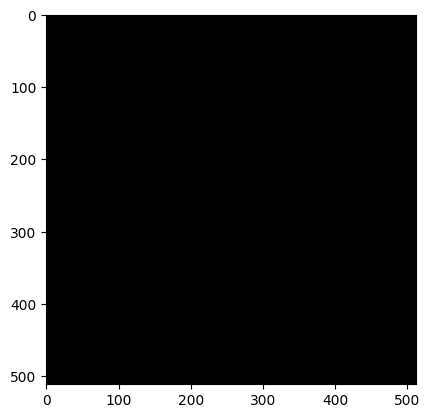

In [ ]:
#show overlay images

img_array_neoplasm = sitk.GetArrayFromImage(neoplasm_segment_img)
print(img_array_neoplasm.shape)
#print(len(input_dcm_new))
#w = widgets.IntSlider(value=0, max=128)

#plt.imshow(slice, cmap='gray') # overlay the original image with the segmentation mask
plt.imshow(img_array_neoplasm[110], cmap='gray') # alpha=0.2 # overlay the segmentation mask with the original image
plt.show()

In [50]:
i = 0
for _, row in path_df.iterrows():
    ct_path = Path(row['path_ct'])
    seg_path = Path(row['path_mask'])
    if i > 0:
        break
    sitk_dcms, result_seg = read_scans(ct_path, seg_path)
    i += 1

ImageSeriesReader (0x56496aaf8130): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.97619



In [ ]:
print(seg.Modality)
print(seg.SOPClassUID)
print(type(seg_reader.read(seg)))

In [ ]:
#show overlay images

neoplasm_segment = result.segment_data(1) # this is the neoplasm segment, but is this always the case?
print(neoplasm_segment.shape)
neoplasm_segment_img = result.segment_image(1) # or should I do this..?
img_array_neoplasm = sitk.GetArrayFromImage(neoplasm_segment_img)
print(img_array_neoplasm.shape)
print(len(input_dcm_new))

plt.imshow(slice, cmap='gray') # overlay the original image with the segmentation mask
plt.imshow(img_array_neoplasm[80], cmap='gray', alpha=0.2) # overlay the segmentation mask with the original image
plt.show()

In [ ]:
#find neoplasm label

for seg_num, info in seg_infos.items():

    #could make this more efficient by stopping the loop if the correct item was found?
    if 'Neoplasm' not in info.get('SegmentLabel', ''):
            continue
    neo_seg_num = seg_num
    neoplasm_segment_img = result_seg.segment_image(neo_seg_num)
